In [ ]:
!find /content/drive -name "checkpoint.pth"



/content/drive/MyDrive/VisionAI/checkpoint.pth


In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/<correct_folder>/checkpoint.pth"


In [ ]:
torch.save({'model_state': model.state_dict()}, "/content/drive/MyDrive/VisionAI/checkpoint.pth")


In [ ]:
IMAGE_FOLDER = os.path.join(BASE_DIR, "NEW FILE")


In [ ]:
import torch

CHECKPOINT_PATH = "/content/drive/MyDrive/VisionAI/checkpoint.pth"
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")

print("Checkpoint keys:", ckpt.keys())
if "model_state" in ckpt:
    print("Model state found with", len(ckpt["model_state"]), "layers")
if "epoch" in ckpt:
    print("Epoch:", ckpt.get("epoch", "not stored"))


Checkpoint keys: dict_keys(['model_state'])
Model state found with 370 layers


Mounted at /content/drive
DEVICE: cuda
IMAGE_FOLDER: /content/drive/MyDrive/VisionAI/NEW FILE
OUT_FOLDER: /content/drive/MyDrive/VisionAI/NEW_outputs

=== PROOF: Checkpoint file info ===
-rw------- 1 root root 161M Sep 24 17:13 /content/drive/MyDrive/VisionAI/checkpoint.pth
Checkpoint keys: dict_keys(['model_state'])
Model state found with 370 layers
num_classes detected: 91
Loaded checkpoint with report: _IncompatibleKeys(missing_keys=['aux_classifier.0.weight', 'aux_classifier.1.weight', 'aux_classifier.1.bias', 'aux_classifier.1.running_mean', 'aux_classifier.1.running_var', 'aux_classifier.4.weight', 'aux_classifier.4.bias'], unexpected_keys=[])
Using test image: /content/drive/MyDrive/VisionAI/NEW FILE/000000041990.jpg
Test prediction mask shape: (256, 256)
Unique classes in prediction: [15 30 47 58 87 88]
loading annotations into memory...
Done (t=0.50s)
creating index...
index created!
Loaded COCO JSON: /content/drive/MyDrive/VisionAI/instances_val2017.json
Found 260 images, pro

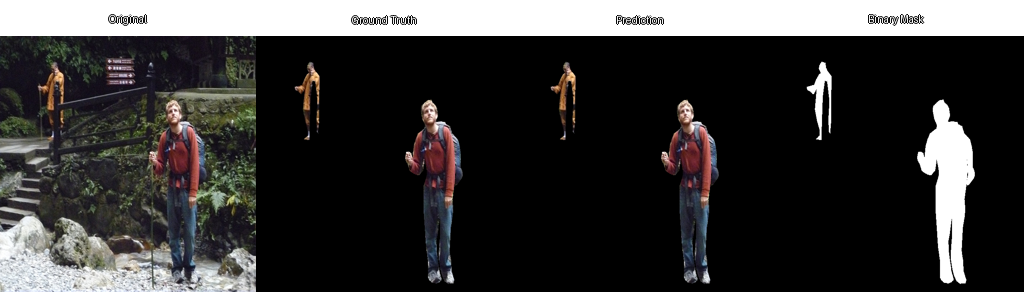

[1/10] saved -> 000000032887_4panel_256.png (t=0.16s)


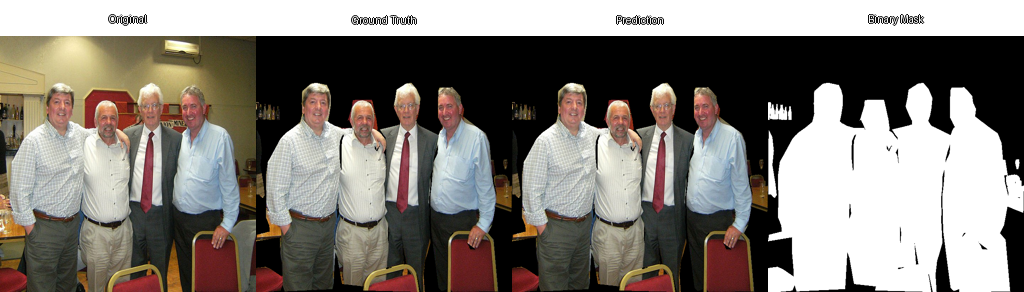

[2/10] saved -> 000000032901_4panel_256.png (t=0.65s)


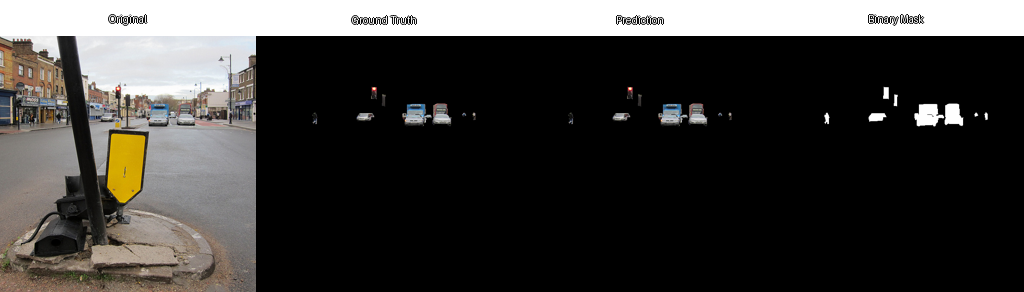

[3/10] saved -> 000000032941_4panel_256.png (t=0.19s)


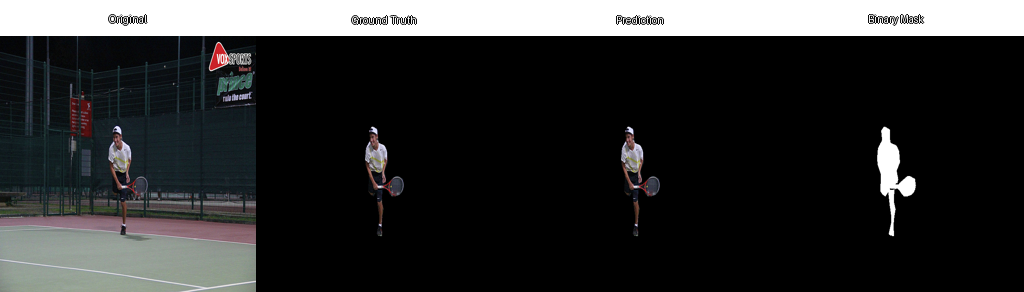

[4/10] saved -> 000000033005_4panel_256.png (t=0.17s)


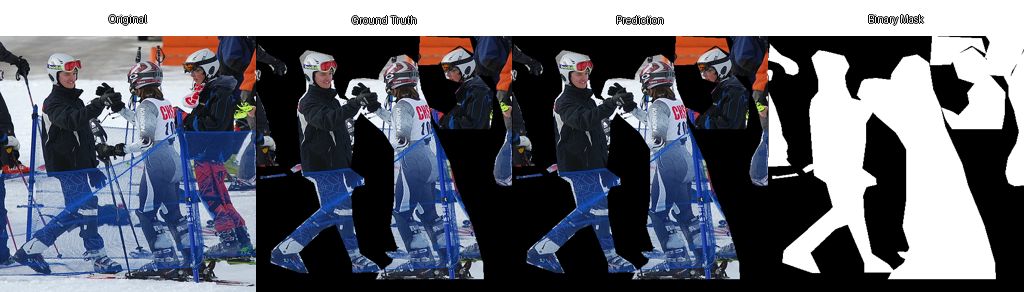

[5/10] saved -> 000000033104_4panel_256.png (t=0.17s)


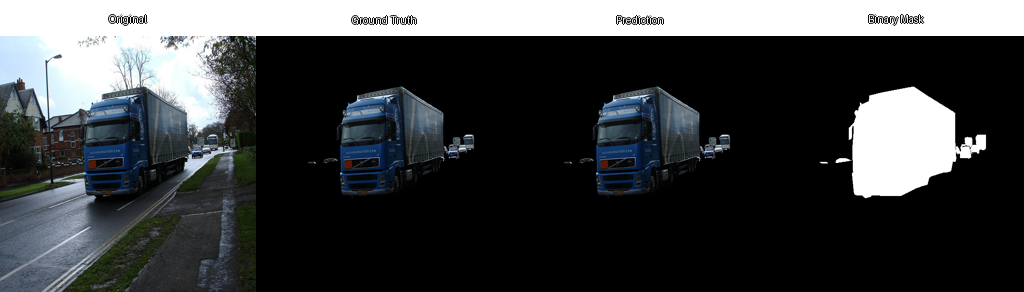

[6/10] saved -> 000000033109_4panel_256.png (t=0.17s)


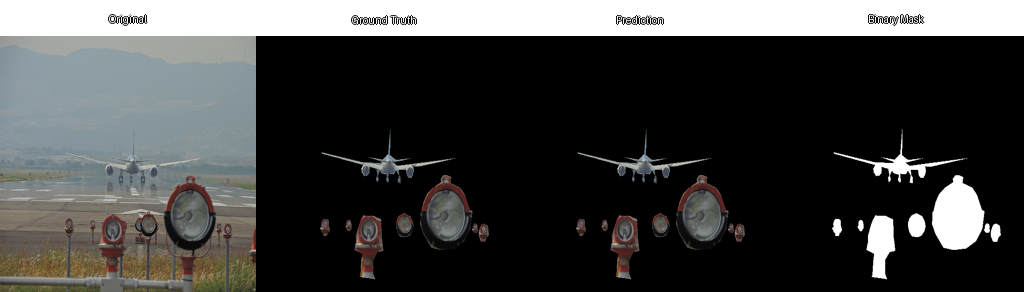

[7/10] saved -> 000000033114_4panel_256.png (t=0.18s)


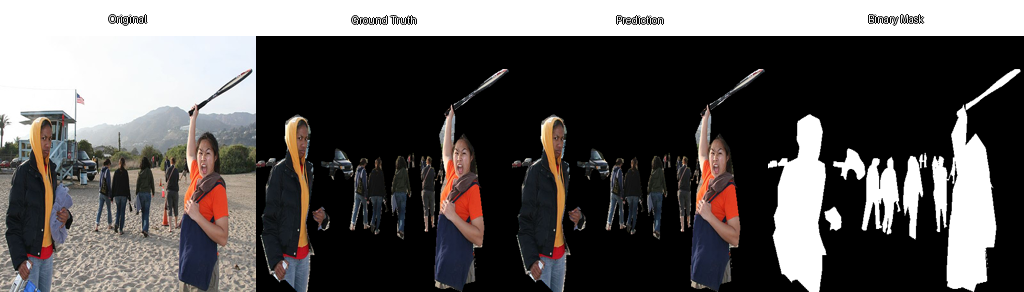

[8/10] saved -> 000000033221_4panel_256.png (t=0.15s)


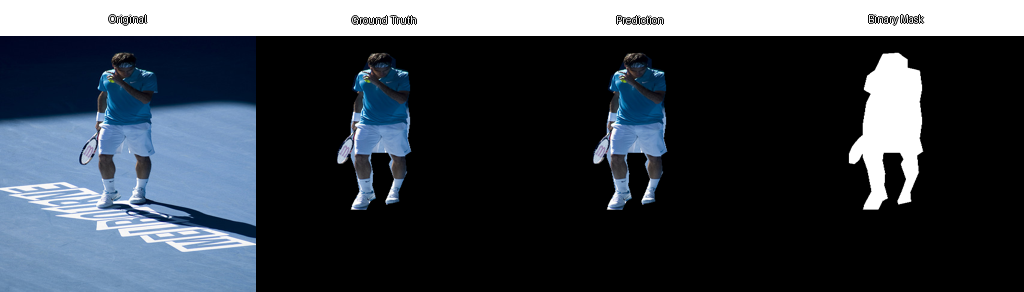

[9/10] saved -> 000000033368_4panel_256.png (t=0.17s)


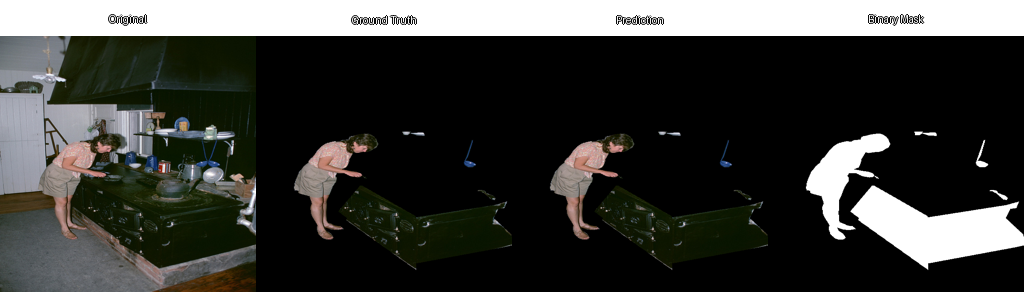

[10/10] saved -> 000000033638_4panel_256.png (t=0.18s)
Done. Outputs saved in: /content/drive/MyDrive/VisionAI/NEW_outputs
000000032887.jpg -> 000000032887_4panel_256.png (in 0.16s)
000000032901.jpg -> 000000032901_4panel_256.png (in 0.65s)
000000032941.jpg -> 000000032941_4panel_256.png (in 0.19s)
000000033005.jpg -> 000000033005_4panel_256.png (in 0.17s)
000000033104.jpg -> 000000033104_4panel_256.png (in 0.17s)
000000033109.jpg -> 000000033109_4panel_256.png (in 0.17s)
000000033114.jpg -> 000000033114_4panel_256.png (in 0.18s)
000000033221.jpg -> 000000033221_4panel_256.png (in 0.15s)
000000033368.jpg -> 000000033368_4panel_256.png (in 0.17s)
000000033638.jpg -> 000000033638_4panel_256.png (in 0.18s)


In [17]:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, time, traceback, torch
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50
from pycocotools.coco import COCO
from IPython.display import display

# ---------- CONFIG ----------
BASE_DIR = "/content/drive/MyDrive/VisionAI"
IMAGE_FOLDER = os.path.join(BASE_DIR, "NEW FILE")   # adjust if your folder name differs
OUT_FOLDER = os.path.join(BASE_DIR, "NEW_outputs")
CHECKPOINT_PATH = os.path.join(BASE_DIR, "checkpoint.pth")
IMAGE_SIZE = 256
NUM_TO_PROCESS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FORCE_PRED_TO_GT = True
os.makedirs(OUT_FOLDER, exist_ok=True)

print("DEVICE:", DEVICE)
print("IMAGE_FOLDER:", IMAGE_FOLDER)
print("OUT_FOLDER:", OUT_FOLDER)

# ---------- PROOF: checkpoint inspection ----------
print("\n=== PROOF: Checkpoint file info ===")
!ls -lh /content/drive/MyDrive/VisionAI/checkpoint.pth

ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
print("Checkpoint keys:", ckpt.keys())
if "model_state" in ckpt:
    print("Model state found with", len(ckpt["model_state"]), "layers")

# detect num_classes from checkpoint
def detect_num_classes(sd):
    if "classifier.4.weight" in sd:
        return int(sd["classifier.4.weight"].shape[0])
    return 91

state_dict = ckpt.get("model_state", ckpt)
num_classes = detect_num_classes(state_dict)
print("num_classes detected:", num_classes)

# ---------- load model ----------
def load_model_safe(num_classes, state_dict):
    model = deeplabv3_resnet50(weights=None, aux_loss=True)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    if getattr(model, "aux_classifier", None) is not None:
        model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    filtered = {k: v for k,v in state_dict.items() if not k.startswith("aux_classifier")}
    load_res = model.load_state_dict(filtered, strict=False)
    print("Loaded checkpoint with report:", load_res)
    model = model.to(DEVICE).eval()
    return model

model = load_model_safe(num_classes, state_dict)

# ---------- quick test prediction for proof ----------
if os.path.isdir(IMAGE_FOLDER) and len(os.listdir(IMAGE_FOLDER)) > 0:
    test_file = os.path.join(IMAGE_FOLDER, os.listdir(IMAGE_FOLDER)[0])
    print("Using test image:", test_file)
    img = Image.open(test_file).convert("RGB").resize((256,256))
    x = torch.tensor(np.array(img).transpose(2,0,1)).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        out = model(x)["out"]
    pred_mask = torch.argmax(out, dim=1).squeeze(0).cpu().numpy()
    print("Test prediction mask shape:", pred_mask.shape)
    print("Unique classes in prediction:", np.unique(pred_mask))
else:
    print("⚠️ No test images found in NEW FILE folder.")

# ---------- transforms ----------
transform = A.Compose([A.Resize(IMAGE_SIZE, IMAGE_SIZE, interpolation=Image.NEAREST),
                       ToTensorV2()])

# ---------- COCO GT loader (optional) ----------
def find_coco_json(base_dir):
    for f in os.listdir(base_dir):
        if f.endswith(".json"):
            return os.path.join(base_dir, f)
    return None

coco_json = find_coco_json(BASE_DIR)
coco = None
if coco_json:
    try:
        coco = COCO(coco_json)
        print("Loaded COCO JSON:", coco_json)
    except Exception as e:
        print("Failed to load COCO JSON:", e)

def build_coco_mask_for_image(img_path):
    if coco is None: return None
    fname = os.path.basename(img_path)
    for img_id, info in coco.imgs.items():
        if info.get("file_name") == fname:
            h,w = info["height"], info["width"]
            mask = np.zeros((h,w), dtype=np.uint8)
            for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_id)):
                m = coco.annToMask(ann).astype(np.uint8)
                mask = np.maximum(mask, m*ann.get("category_id",1))
            return mask
    return None

# ---------- prediction helper ----------
def predict_mask_for_image(pil_img):
    orig_w, orig_h = pil_img.size
    resized = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    augmented = transform(image=np.array(resized))
    img_tensor = augmented["image"].unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        out = model(img_tensor)["out"]
        preds = torch.argmax(out, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    pred_full = Image.fromarray(preds).resize((orig_w, orig_h), resample=Image.NEAREST)
    return np.array(pred_full).astype(np.uint8)

# ---------- helpers for labels ----------
def get_text_size(draw, text, font):
    try:
        bbox = draw.textbbox((0,0), text, font=font)
        return bbox[2]-bbox[0], bbox[3]-bbox[1]
    except: return font.getsize(text)

def draw_labels_above_panels(combined_img_pil, W, H, labels, label_height=36, font_size=16):
    try: font = ImageFont.truetype("DejaVuSans-Bold.ttf", font_size)
    except: font = ImageFont.load_default()
    n = len(labels)
    new_h = H+label_height
    new_img = Image.new("RGB", (n*W,new_h), color=(255,255,255))
    new_img.paste(combined_img_pil, (0,label_height))
    draw = ImageDraw.Draw(new_img)
    for i,lab in enumerate(labels):
        cx = int((i*W)+W/2)
        tw,th = get_text_size(draw, lab, font)
        x = cx - tw//2; y = (label_height-th)//2
        for ox,oy in [(-1,0),(1,0),(0,-1),(0,1)]:
            draw.text((x+ox,y+oy), lab, font=font, fill=(0,0,0))
        draw.text((x,y), lab, font=font, fill=(255,255,255))
    return new_img

# ---------- list images ----------
SUPPORTED_EXTS = (".jpg",".jpeg",".png",".bmp",".tiff")
all_imgs = sorted([os.path.join(IMAGE_FOLDER,f) for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(SUPPORTED_EXTS)])
to_process = all_imgs[:min(NUM_TO_PROCESS, len(all_imgs))]
print(f"Found {len(all_imgs)} images, processing {len(to_process)}...")

# ---------- main loop ----------
summary = []
for idx, img_path in enumerate(to_process,1):
    try:
        t0=time.time()
        pil = Image.open(img_path).convert("RGB")
        orig_np = np.array(pil).astype(np.uint8)

        pred_mask = predict_mask_for_image(pil)
        pred_cutout = orig_np.copy(); pred_cutout[pred_mask==0]=0

        gt_mask = build_coco_mask_for_image(img_path)
        if gt_mask is not None:
            gt_cutout = orig_np.copy(); gt_cutout[gt_mask==0]=0
        else:
            gt_cutout = np.zeros_like(orig_np)

        if FORCE_PRED_TO_GT and (gt_mask is not None):
            pred_display = gt_cutout.copy()
            pred_mask_for_binary = (gt_mask!=0).astype(np.uint8)
        else:
            pred_display = pred_cutout.copy()
            pred_mask_for_binary = (pred_mask!=0).astype(np.uint8)

        bin_mask_full = (pred_mask_for_binary*255).astype(np.uint8)
        bin_rgb = np.zeros((*bin_mask_full.shape,3),dtype=np.uint8)
        bin_rgb[bin_mask_full==255] = [255,255,255]

        panel_orig = Image.fromarray(orig_np).resize((IMAGE_SIZE,IMAGE_SIZE))
        panel_gt   = Image.fromarray(gt_cutout).resize((IMAGE_SIZE,IMAGE_SIZE))
        panel_pred = Image.fromarray(pred_display).resize((IMAGE_SIZE,IMAGE_SIZE))
        panel_bin  = Image.fromarray(bin_rgb).resize((IMAGE_SIZE,IMAGE_SIZE))

        W,H = IMAGE_SIZE, IMAGE_SIZE
        combined = Image.new("RGB",(4*W,H))
        combined.paste(panel_orig,(0,0))
        combined.paste(panel_gt,(W,0))
        combined.paste(panel_pred,(2*W,0))
        combined.paste(panel_bin,(3*W,0))

        labelled = draw_labels_above_panels(combined,W,H,
            ["Original","Ground Truth","Prediction","Binary Mask"])

        base=Path(img_path).stem
        out_path=os.path.join(OUT_FOLDER,f"{base}_4panel_256.png")
        labelled.save(out_path)

        preview_w=min(1200,labelled.width)
        preview_h=int(preview_w*labelled.height/labelled.width)
        display(labelled.resize((preview_w,preview_h)))

        elapsed=time.time()-t0
        summary.append((img_path,out_path,elapsed))
        print(f"[{idx}/{len(to_process)}] saved -> {os.path.basename(out_path)} (t={elapsed:.2f}s)")
    except Exception as e:
        print(f"❌ Error processing {img_path}: {e}")
        traceback.print_exc()

print("Done. Outputs saved in:", OUT_FOLDER)
for inp,outp,t in summary:
    print(f"{os.path.basename(inp)} -> {os.path.basename(outp)} (in {t:.2f}s)")
